In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ruta_energia = "energiasedif1(11 pisosycomunes).csv"
ruta_agua = "VOLUMENAGUACALIENTECONSUMIDA.csv"

df_energia = pd.read_csv(ruta_energia)
df_agua = pd.read_csv(ruta_agua)

In [8]:
# renombrar la primera columna como 'fecha'
df_energia = df_energia.rename(columns={df_energia.columns[0]: "fecha"})
df_agua = df_agua.rename(columns={df_agua.columns[0]: "fecha"})

# convertir fecha
df_energia["fecha"] = pd.to_datetime(df_energia["fecha"], errors="coerce")
df_agua["fecha"] = pd.to_datetime(df_agua["fecha"], errors="coerce")

# eliminar filas iniciales vacías
cols_energia_sin_fecha = df_energia.columns[1:]
cols_agua_sin_fecha = df_agua.columns[1:]

mask_energia = df_energia[cols_energia_sin_fecha].notna().any(axis=1)
mask_agua = df_agua[cols_agua_sin_fecha].notna().any(axis=1)

primera_fila_energia = mask_energia.idxmax()
primera_fila_agua = mask_agua.idxmax()

df_energia = df_energia.loc[primera_fila_energia:].reset_index(drop=True)
df_agua = df_agua.loc[primera_fila_agua:].reset_index(drop=True)

In [11]:
cols_pisos_energia = [c for c in df_energia.columns if c.startswith("energia") and c != "energia"]
cols_pisos_agua = [c for c in df_agua.columns if c.startswith("volumen")]

print("Columnas energía por piso:")
print(cols_pisos_energia)

print("\nColumnas agua por piso:")
print(cols_pisos_agua)

Columnas energía por piso:
['energiaBA', 'energiaBB', 'energia1C', 'energia2A', 'energia2B', 'energia3A', 'energia3B', 'energia4A', 'energia4B', 'energia5A', 'energia5B']

Columnas agua por piso:
['volumenBA', 'volumenBB', 'volumen1C', 'volumen2A', 'volumen2B', 'volumen3A', 'volumen3B', 'volumen4A', 'volumen4B', 'volumen5A', 'volumen5B']


In [12]:
for col in cols_pisos_energia + ["energia"]:
    df_energia[col] = pd.to_numeric(df_energia[col], errors="coerce")

for col in cols_pisos_agua:
    df_agua[col] = pd.to_numeric(df_agua[col], errors="coerce")

In [13]:
df_energia_diff = df_energia.copy()
df_agua_diff = df_agua.copy()

for col in cols_pisos_energia + ["energia"]:
    df_energia_diff[col] = df_energia_diff[col].diff()

for col in cols_pisos_agua:
    df_agua_diff[col] = df_agua_diff[col].diff()

In [14]:
df_energia_diff.head()

,fecha,POTENCIA ACTIVA,energia,etermicaconserje,CAUDAL AGUA CALIENTE,erefrigeración conserje,etermicasolar,energiaBA,energiaBB,energia1C,energia2A,energia2B,energia3A,energia3B,energia4A,energia4B,energia5A,energia5B
0,2025-02-27 11:00:00,0.33,NaN,39154.7,595.30,135861.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-27 12:00:00,0.31,0.31,39155.7,598.60,135861.0,0.0,1.25,2.00,2.73,4.0,4.00,0.0,0.0,0.0,1.71,0.0,0.0
2,2025-02-27 13:00:00,0.29,0.30,39156.2,595.10,135861.0,0.0,1.49,2.25,2.75,4.0,4.00,0.0,0.0,0.0,1.75,0.0,0.0
3,2025-02-27 14:00:00,0.62,0.40,39157.0,598.25,135861.0,0.0,1.01,1.75,2.27,4.0,3.77,0.0,0.0,0.0,1.54,0.0,0.0
4,2025-02-27 15:00:00,0.33,0.54,39157.0,597.95,135861.0,0.0,1.25,2.00,2.25,4.0,3.23,0.0,0.0,0.0,1.21,0.0,0.0


In [15]:
df_agua_diff.head()

,fecha,volumenBA,volumenBB,volumen1C,volumen2A,volumen2B,volumen3A,volumen3B,volumen4A,volumen4B,volumen5A,volumen5B
0,2025-02-27 11:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-02-27 12:00:00,5.70,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
2,2025-02-27 13:00:00,1.50,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00
3,2025-02-27 14:00:00,0.27,0.0,0.0,1.72,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,2025-02-27 15:00:00,0.00,0.0,0.0,0.28,0.0,0.0,0.0,0.0,0.0,0.0,1.35


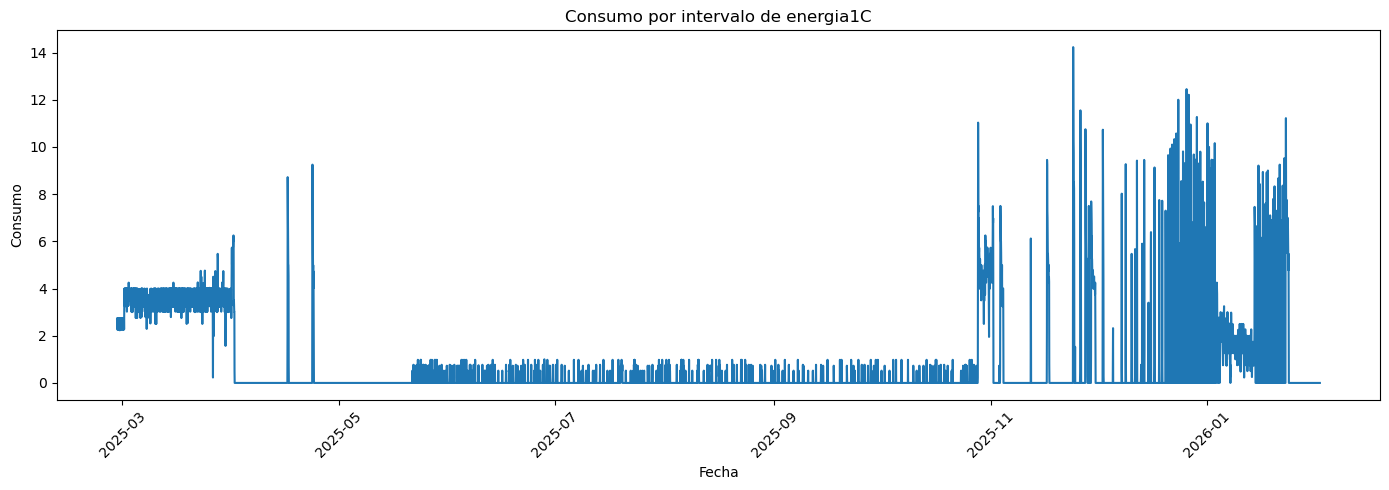

In [22]:
col_ejemplo = cols_pisos_energia[2]

plt.figure(figsize=(14,5))
plt.plot(df_energia_diff["fecha"], df_energia_diff[col_ejemplo])
plt.title(f"Consumo por intervalo de {col_ejemplo}")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
def plot_month_apartment(
    df_energia_diff,
    df_agua_diff,
    data_type="agua",
    apartment="volumen1C",
    year=2025,
    month=11,
    daily=False,
    kind="line"
):
    """
    Plot energy or water consumption for one apartment in a chosen month and year.

    Parameters
    ----------
    df_energia_diff : pandas.DataFrame
        DataFrame with non-cumulative energy data. Must contain a 'fecha' column.
    df_agua_diff : pandas.DataFrame
        DataFrame with non-cumulative water data. Must contain a 'fecha' column.
    data_type : str
        'energia' or 'agua'
    apartment : str
        Example: 'energia1C' or 'volumen1C'
    year : int
        Year to plot
    month : int
        Month to plot (1 to 12)
    daily : bool
        If True, aggregates by day inside the selected month
    kind : str
        'line' or 'bar'
    """

    # Validate inputs
    if data_type not in ["energia", "agua"]:
        raise ValueError("data_type must be 'energia' or 'agua'")

    if not 1 <= month <= 12:
        raise ValueError("month must be between 1 and 12")

    if kind not in ["line", "bar"]:
        raise ValueError("kind must be 'line' or 'bar'")

    # Select dataframe
    if data_type == "energia":
        df = df_energia_diff.copy()
        ylabel = "Energy consumption"
    else:
        df = df_agua_diff.copy()
        ylabel = "Water consumption"

    # Check fecha column
    if "fecha" not in df.columns:
        raise ValueError("The selected dataframe must contain a 'fecha' column")

    # Convert fecha to datetime
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

    # Check apartment column
    if apartment not in df.columns:
        raise ValueError(f"'{apartment}' is not a column in the selected dataframe")

    # Keep only selected month and year
    df_plot = df[
        (df["fecha"].dt.year == year) &
        (df["fecha"].dt.month == month)
    ].copy()

    if df_plot.empty:
        print(f"No data found for {apartment} in {year}-{month:02d}")
        return

    # Keep only the columns we need
    df_plot = df_plot[["fecha", apartment]].dropna()

    if df_plot.empty:
        print(f"No non-null data found for {apartment} in {year}-{month:02d}")
        return

    # Aggregate daily if requested
    if daily:
        df_plot = df_plot.set_index("fecha").resample("D").sum().reset_index()
        title_period = f"{year}-{month:02d} (daily)"
    else:
        title_period = f"{year}-{month:02d}"

    # Plot
    plt.figure(figsize=(14, 5))

    if kind == "line":
        plt.plot(df_plot["fecha"], df_plot[apartment], marker="o")
    elif kind == "bar":
        plt.bar(df_plot["fecha"].astype(str), df_plot[apartment])

    plt.title(f"{data_type.capitalize()} consumption - {apartment} - {title_period}")
    plt.xlabel("Date")
    plt.ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

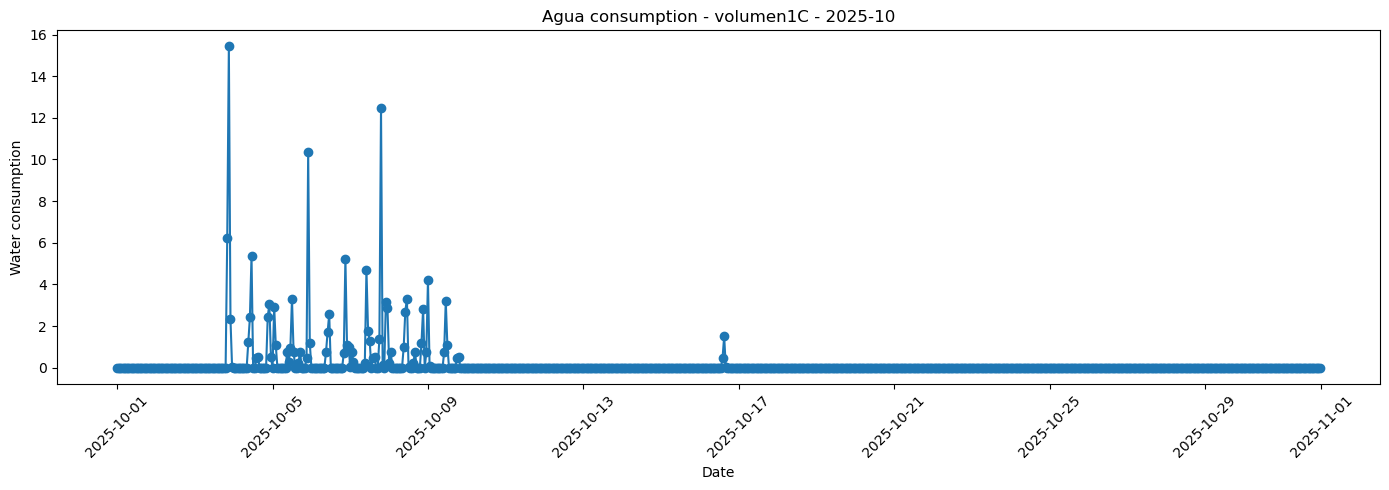

In [37]:
plot_month_apartment(df_energia_diff, df_agua_diff,month=10)